In [2]:
import pandas as pd
print(pd.__version__)

2.2.2


In [3]:
import pandas as pd

sales = pd.read_csv("../data/sales_data.csv")
ingredients = pd.read_csv("../data/ingredients_data.csv")

# Display first 5 rows
sales.head() 
ingredients.head()


,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0


In [3]:
import os
print(os.getcwd())
print(os.listdir("../data"))


c:\Users\Aarthi\Desktop\DS_Dominoz_Project\notebooks
['ingredients_data.csv', 'sales_data.csv']


In [5]:
# Check dataset shape
print("Sales shape:", sales.shape)
print("Ingredients shape:", ingredients.shape)

# Check column names
print(sales.columns)
print(ingredients.columns)

# Check missing values
print(sales.isnull().sum())
print(ingredients.isnull().sum())


Sales shape: (48620, 12)
Ingredients shape: (518, 4)
Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')
Index(['pizza_name_id', 'pizza_name', 'pizza_ingredients',
       'Items_Qty_In_Grams'],
      dtype='object')
pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64
pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    4
dtype: int64


In [6]:
sales.head()
sales['quantity'].describe()


count    48620.000000
mean         1.019622
std          0.143077
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: quantity, dtype: float64

In [7]:
# Handle missing values
mean_qty = ingredients['Items_Qty_In_Grams'].mean()
ingredients['Items_Qty_In_Grams'] = ingredients['Items_Qty_In_Grams'].fillna(mean_qty)

# Verify
ingredients.isnull().sum()


pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    0
dtype: int64

In [8]:

# Aggregate ingredient demand
ingredient_demand = ingredients.groupby('pizza_ingredients')['Items_Qty_In_Grams'].sum()

# Top 10 most used ingredients
ingredient_demand.sort_values(ascending=False).head(10)

pizza_ingredients
Red Onions          1740.0
Chicken             1500.0
Capocollo           1200.0
Tomatoes            1170.0
Mushrooms            840.0
Spinach              720.0
Pepperoni            650.0
Garlic               600.0
Beef Chuck Roast     570.0
Bacon                420.0
Name: Items_Qty_In_Grams, dtype: float64

In [9]:
# Average daily ingredient usage
daily_avg = ingredient_demand / ingredients['pizza_name_id'].nunique()

daily_avg.sort_values(ascending=False).head(10)

reorder_days = 7
purchase_order = daily_avg * reorder_days
purchase_order.sort_values(ascending=False).head(10)



pizza_ingredients
Red Onions          133.846154
Chicken             115.384615
Capocollo            92.307692
Tomatoes             90.000000
Mushrooms            64.615385
Spinach              55.384615
Pepperoni            50.000000
Garlic               46.153846
Beef Chuck Roast     43.846154
Bacon                32.307692
Name: Items_Qty_In_Grams, dtype: float64

In [ ]:
print(sales.columns)

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')


In [11]:
import pandas as pd

# Load datasets
sales = pd.read_csv("../data/sales_data.csv")
ingredients = pd.read_csv("../data/ingredients_data.csv")

# Convert date safely
sales["order_date"] = pd.to_datetime(
    sales["order_date"],
    dayfirst=True,
    errors="coerce"
)

sales = sales.dropna(subset=["order_date"])

# Merge datasets
merged = pd.merge(
    sales,
    ingredients,
    on="pizza_name_id"
)

# Calculate total ingredient usage
merged["total_ingredient_usage"] = (
    merged["quantity"] * merged["Items_Qty_In_Grams"]
)

# Group using correct ingredient column
daily_usage = (
    merged.groupby(["order_date", "pizza_ingredients_y"])
    ["total_ingredient_usage"]
    .sum()
    .reset_index()
)

# Average daily usage per ingredient
avg_daily_usage = (
    daily_usage.groupby("pizza_ingredients_y")
    ["total_ingredient_usage"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_daily_usage.head(10))


pizza_ingredients_y
Chicken       2759.859155
Red Onions    2426.760563
Capocollo     2250.352113
Tomatoes      1672.887324
Bacon         1366.760563
Pepperoni     1216.478873
Mushrooms     1043.802817
Garlic         884.929577
Spinach        854.260563
Corn           790.985915
Name: total_ingredient_usage, dtype: float64


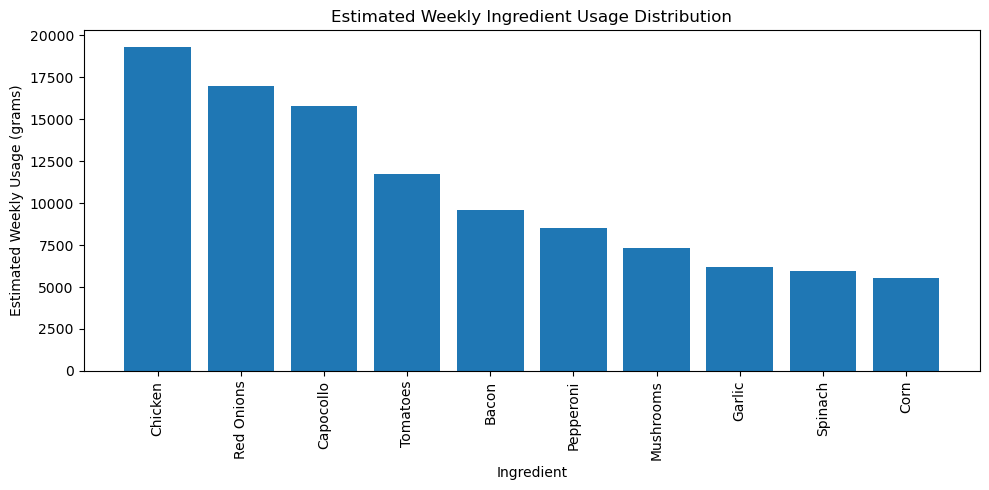

In [12]:
top_10_daily_usage = avg_daily_usage.head(10)

weekly_usage = top_10_daily_usage * 7

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(weekly_usage.index, weekly_usage.values)

plt.xticks(rotation=90)
plt.xlabel("Ingredient")
plt.ylabel("Estimated Weekly Usage (grams)")
plt.title("Estimated Weekly Ingredient Usage Distribution")

plt.tight_layout()
plt.show()



In [13]:
import os
print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())


Current working directory:
c:\Users\Aarthi\Desktop\DS_Dominoz_Project\notebooks

Files here:
['dominoz_analysis.ipynb']


In [14]:
import pandas as pd

sales = pd.read_csv("../data/sales_data.csv")

daily_avg = sales['quantity'].mean()
weekly_avg = sales['quantity'].sum() / 7

print("Daily Average Quantity (units):", daily_avg)
print("Weekly Average Quantity (units):", weekly_avg)


Daily Average Quantity (units): 1.0196215549156726
Weekly Average Quantity (units): 7082.0


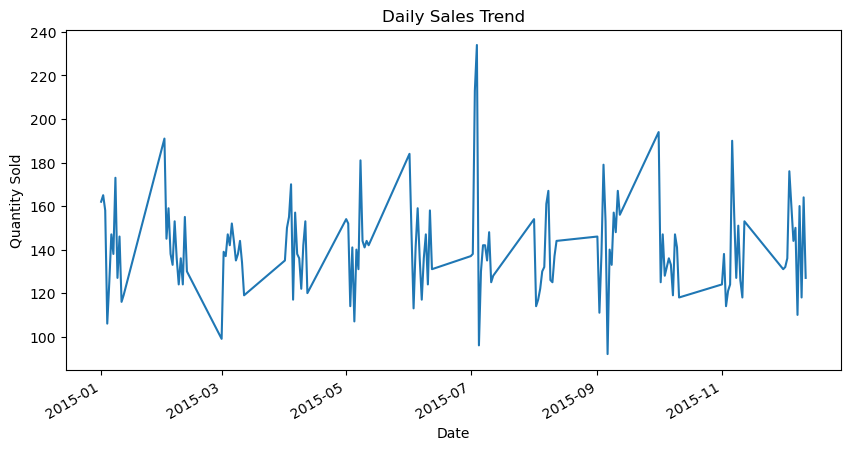

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/sales_data.csv")

sales["order_date"] = pd.to_datetime(
    sales["order_date"],
    dayfirst=True,
    errors="coerce"
)

daily_sales = sales.groupby("order_date")["quantity"].sum()

plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()


In [16]:
daily_sales.head(10)


order_date
2015-01-01    162
2015-01-02    165
2015-01-03    158
2015-01-04    106
2015-01-05    125
2015-01-06    147
2015-01-07    138
2015-01-08    173
2015-01-09    127
2015-01-10    146
Name: quantity, dtype: int64

In [20]:
category_sales = sales.groupby('pizza_category')['quantity'].sum().reset_index()
category_sales['percentage'] = (
    category_sales['quantity'] / category_sales['quantity'].sum()
) * 100

category_sales['percentage'] = category_sales['percentage'].round(2)

print(category_sales)



  pizza_category  quantity  percentage
0        Chicken     11047       22.29
1        Classic     14881       30.03
2        Supreme     11981       24.18
3         Veggie     11642       23.49


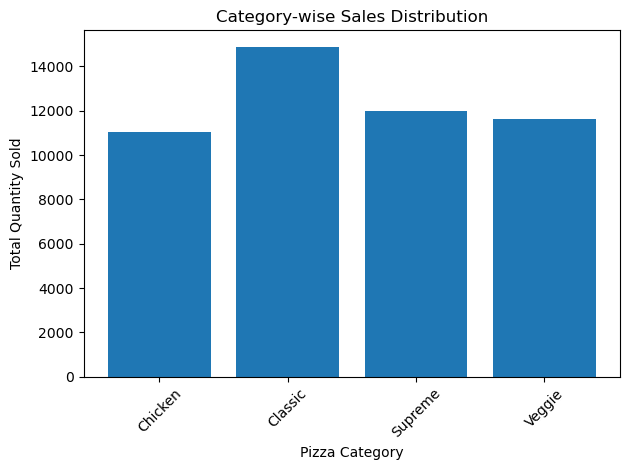

In [21]:
plt.figure()
plt.bar(category_sales['pizza_category'], category_sales['quantity'])

plt.xlabel("Pizza Category")
plt.ylabel("Total Quantity Sold")
plt.title("Category-wise Sales Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


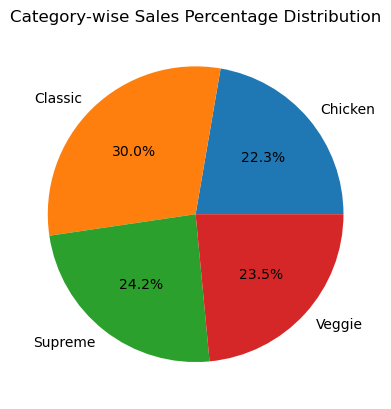

In [22]:
plt.figure()
plt.pie(category_sales['quantity'],
        labels=category_sales['pizza_category'],
        autopct='%1.1f%%')

plt.title("Category-wise Sales Percentage Distribution")
plt.show()


In [11]:
import os
print(os.listdir(".."))


['.ipynb_checkpoints', 'app.py', 'app.py_folder', 'data', 'notebooks', 'requirements.txt', 'Untitled Folder', 'Untitled.ipynb']


import os
os.listdir("../data")


In [12]:
import os
os.listdir("../data")


['ingredients_data.csv', 'sales_data.csv']

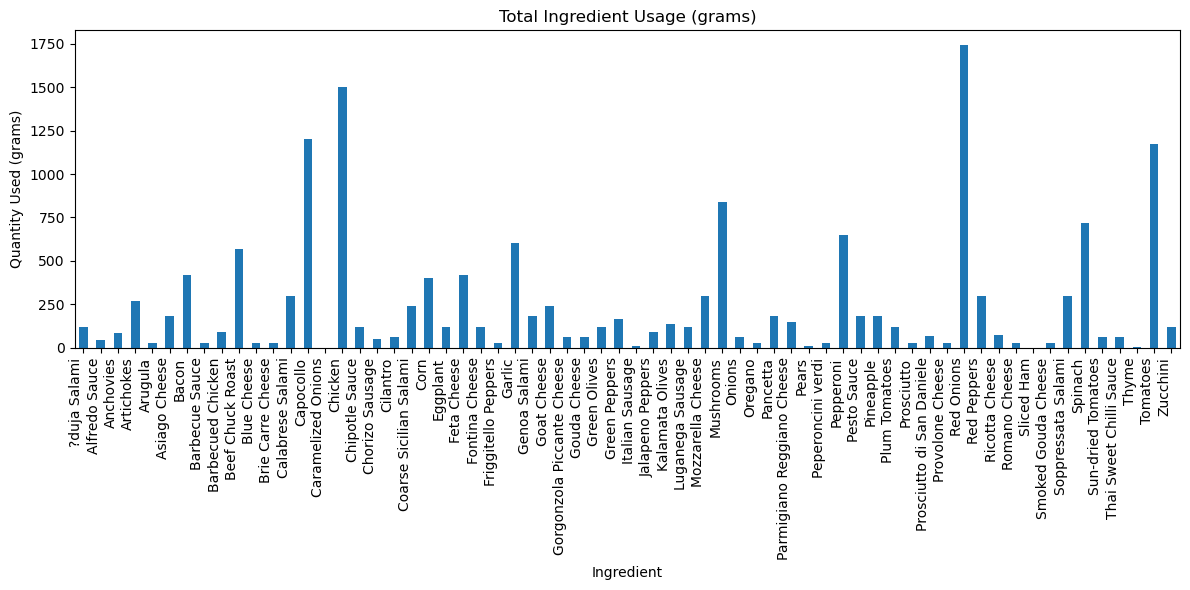

In [24]:
import matplotlib.pyplot as plt

ingredient_usage = ingredients.groupby("pizza_ingredients")["Items_Qty_In_Grams"].sum()

plt.figure(figsize=(12, 6))
ingredient_usage.plot(kind="bar")
plt.title("Total Ingredient Usage (grams)")
plt.xlabel("Ingredient")
plt.ylabel("Quantity Used (grams)")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()


In [26]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# Load ingredient data
ingredients = pd.read_csv("../data/ingredients_data.csv")

# Drop missing values
ingredients = ingredients.dropna(subset=["Items_Qty_In_Grams"])

# Create time index
ingredients["day"] = np.arange(len(ingredients))

# Features and target
X = ingredients[["day"]]
y = ingredients["Items_Qty_In_Grams"]

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next day
future_day = pd.DataFrame({"day": [len(ingredients)]})
predicted_qty = model.predict(future_day)

print(
    "Predicted Next Day Ingredient Quantity (grams):",
    round(predicted_qty[0], 2)
)



Predicted Next Day Ingredient Quantity (grams): 30.22


In [7]:
import pandas as pd

# Load sales data (daily aggregated sales required)
sales = pd.read_csv("../data/sales_data.csv")

# Convert date column to datetime
sales["order_date"] = pd.to_datetime(
    sales["order_date"],
    dayfirst=True,
    errors="coerce"
)
# Aggregate daily sales
daily_sales = sales.groupby("order_date")["quantity"].sum().reset_index()

# Calculate 7-day moving average
daily_sales["7_day_MA"] = daily_sales["quantity"].rolling(window=7).mean()

# Predict next day sales using last 7-day average
predicted_sales = daily_sales["7_day_MA"].iloc[-1]

print("Predicted Next Day Sales (7-Day Moving Average):",
      round(predicted_sales, 2))

Predicted Next Day Sales (7-Day Moving Average): 139.0


Predicted Next Day Sales (7-Day Moving Average): 139.0


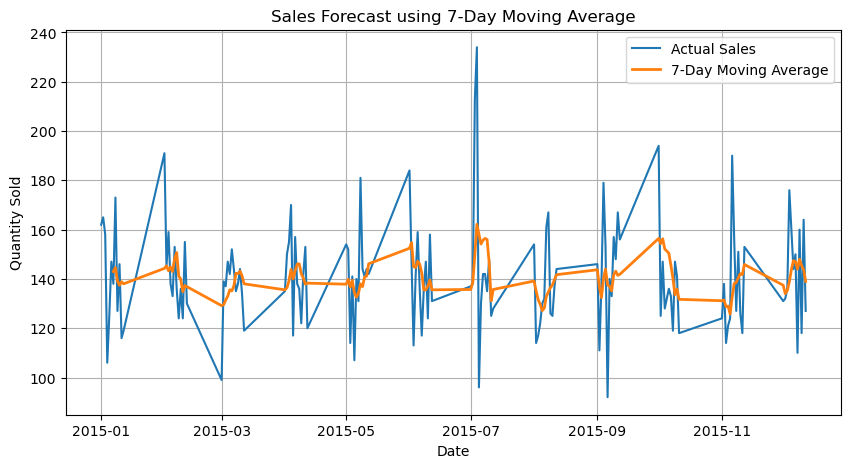

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
sales = pd.read_csv("../data/sales_data.csv")

# Convert date
sales["order_date"] = pd.to_datetime(sales["order_date"], dayfirst=True, errors="coerce")

# Aggregate daily sales
daily_sales = sales.groupby("order_date")["quantity"].sum().sort_index()

# Calculate 7-day moving average
daily_sales_ma = daily_sales.rolling(window=7).mean()

# Predict next day using last 7-day average
next_day_forecast = daily_sales.tail(7).mean()

print("Predicted Next Day Sales (7-Day Moving Average):", round(next_day_forecast, 2))

# Plot actual vs moving average
plt.figure(figsize=(10,5))
plt.plot(daily_sales, label="Actual Sales")
plt.plot(daily_sales_ma, label="7-Day Moving Average", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.title("Sales Forecast using 7-Day Moving Average")
plt.legend()
plt.grid(True)
plt.show()

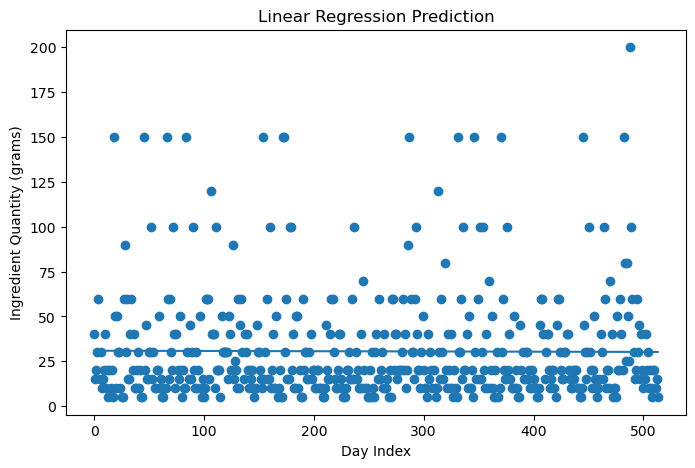

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(X, y)
plt.plot(X, model.predict(X))

plt.xlabel("Day Index")
plt.ylabel("Ingredient Quantity (grams)")
plt.title("Linear Regression Prediction")

plt.show()


In [28]:
# Safety stock and current stock (in grams)
safety_stock = 20
current_stock = 50

# Purchase order calculation
purchase_order = max(predicted_qty[0] + safety_stock - current_stock, 0)

print("Purchase Order Quantity (grams):", round(purchase_order))


Purchase Order Quantity (grams): 0


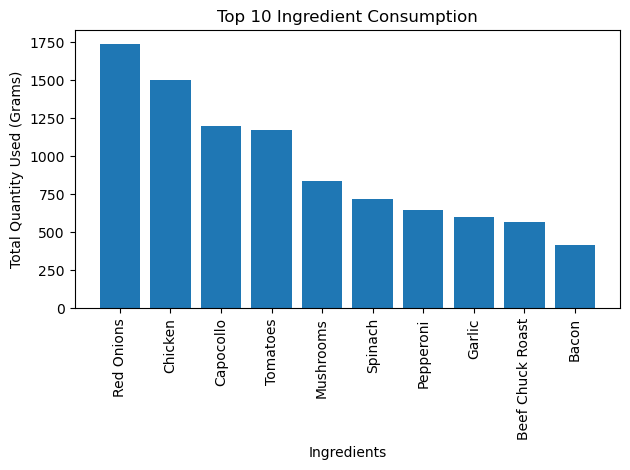

In [19]:
top_ingredients = ingredient_demand.head(10)

plt.figure()
plt.bar(top_ingredients['pizza_ingredients'],
        top_ingredients['Items_Qty_In_Grams'])

plt.xlabel("Ingredients")
plt.ylabel("Total Quantity Used (Grams)")
plt.title("Top 10 Ingredient Consumption")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


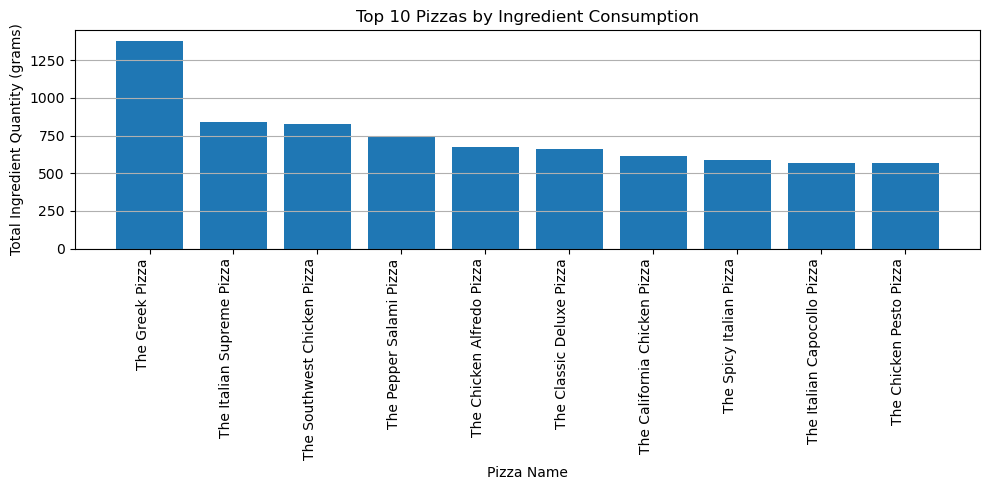

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
ingredients = pd.read_csv("../data/ingredients_data.csv")

# Aggregate ingredient quantity by pizza name
pizza_consumption = (
    ingredients.groupby("pizza_name")["Items_Qty_In_Grams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10,5))
plt.bar(pizza_consumption.index, pizza_consumption.values)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Pizza Name")
plt.ylabel("Total Ingredient Quantity (grams)")
plt.title("Top 10 Pizzas by Ingredient Consumption")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


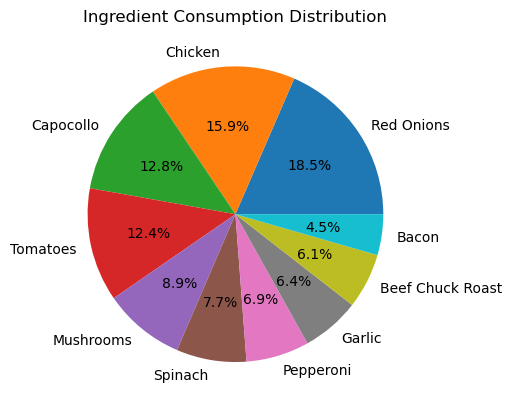

In [25]:
plt.figure()
plt.pie(top_ingredients['Items_Qty_In_Grams'],
        labels=top_ingredients['pizza_ingredients'],
        autopct='%1.1f%%')

plt.title("Ingredient Consumption Distribution")
plt.show()



In [7]:
import pandas as pd

# Load dataset
sales = pd.read_csv("../data/sales_data.csv")

# Convert order_time to datetime
sales["order_time"] = pd.to_datetime(sales["order_time"],format="%I:%M:%S %p"
)

# Extract hour
sales["order_hour"] = sales["order_time"].dt.hour

# Aggregate quantity by hour
hourly_demand = (
    sales.groupby("order_hour")["quantity"]
    .sum()
    .reset_index()
)

print(hourly_demand)


    order_hour  quantity
0            9         4
1           10        18
2           11      2728
3           12      6776
4           13      6413
5           14      3613
6           15      3216
7           16      4239
8           17      5211
9           18      5417
10          19      4406
11          20      3534
12          21      2545
13          22      1386
14          23        68
